In [76]:

from pathlib import Path
import torch
import pandas as pd



### Setup save directory to save the data 

### Load data and validate the data 

In [ ]:
from src.dataloader import LoadForecastDataLoader

loader = LoadForecastDataLoader(

    csv_path="Data/synthetic_ireland_national_hourly.csv",

    datetime_col="timestamp_local",
    # datetime_format="%Y-%m-%dT%H:%M:%S%z", # define a datetime format if the datetime column is not in a standard format
    features=[
        "hour", "day_of_week", "month",
        "mean_wind_speed", "wind_capacity_weighted_wind_speed","wind_speed_squared","wind_speed_lag_1h",
        "mean_temperature","temperature_lag_1h",
    ],

    target="wind_generation_mw",

    lookback=48,

    horizon=24,

    expected_frequency="1h"
)

In [48]:
from src.dataloader import LoadForecastDataLoader

loader = LoadForecastDataLoader(

    csv_path="Data/synthetic_ireland_national_hourly.csv",

    datetime_col="timestamp_local",
    # datetime_format="%Y-%m-%dT%H:%M:%S%z", # define a datetime format if the datetime column is not in a standard format
    features=[
        "hour", "day_of_week", "month",
        "mean_wind_speed", "consumption_lag_1h","consumption_lag_24h",
        "mean_temperature","temperature_lag_1h",
    ],

    target="total_electricity_consumption_mw",

    lookback=48,

    horizon=24,

    expected_frequency="1h"
)

In [ ]:

# ============================================================
# Model save directory
# ============================================================

SAVE_DIR = Path(f"models/consumption/{loader.lookback}_lookback_{loader.horizon}_horizon_syn")

SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = SAVE_DIR / "best_lstm.pt"

In [49]:
df_all = loader.get_dataframe()

In [50]:
df_all

,timestamp_local,timestamp_utc,hour,day_of_week,month,weekend_flag,season,daylight_flag,mean_temperature,population_weighted_temperature,...,wind_generation_mw,solar_generation_mw,gas_generation_mw,other_generation_mw,renewable_generation_mw,renewable_generation_percentage,net_exports_mw,consumption_lag_1h,consumption_lag_24h,random_control
0,2022-01-01 00:00:00+00:00,2022-01-01T00:00:00+00:00,0,5,1,1,winter,0,1.28,1.19,...,1346.9,0.0,2071.1,567.5,1346.9,33.80,20.8,4396.2,4061.7,-0.51891
1,2022-01-01 01:00:00+00:00,2022-01-01T01:00:00+00:00,1,5,1,1,winter,0,1.64,1.57,...,1553.2,0.0,1593.1,571.1,1553.2,41.78,41.3,3964.7,4049.0,-0.21422
2,2022-01-01 02:00:00+00:00,2022-01-01T02:00:00+00:00,2,5,1,1,winter,0,0.57,0.46,...,1436.1,0.0,1732.7,576.8,1436.1,38.34,-15.3,3676.1,3926.0,0.46331
3,2022-01-01 03:00:00+00:00,2022-01-01T03:00:00+00:00,3,5,1,1,winter,0,0.15,-0.02,...,2370.6,0.0,882.2,589.2,2370.6,61.70,128.6,3760.9,3887.3,-0.14404
4,2022-01-01 04:00:00+00:00,2022-01-01T04:00:00+00:00,4,5,1,1,winter,0,-0.08,-0.28,...,1655.3,0.0,1666.3,613.4,1655.3,42.07,102.1,3713.4,4013.0,-0.44085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2024-12-31 19:00:00+00:00,2024-12-31T19:00:00+00:00,19,1,12,0,winter,0,9.42,9.72,...,1419.9,0.0,2452.2,587.7,1419.9,31.84,29.3,4526.7,4583.9,0.54431
26300,2024-12-31 20:00:00+00:00,2024-12-31T20:00:00+00:00,20,1,12,0,winter,0,8.83,9.16,...,969.6,0.0,2504.7,619.6,969.6,23.68,-135.2,4430.5,4409.9,1.29025
26301,2024-12-31 21:00:00+00:00,2024-12-31T21:00:00+00:00,21,1,12,0,winter,0,8.99,9.20,...,846.6,0.0,2606.5,623.6,846.6,20.77,-89.6,4229.1,4164.1,-1.05788
26302,2024-12-31 22:00:00+00:00,2024-12-31T22:00:00+00:00,22,1,12,0,winter,0,8.92,9.16,...,686.6,0.0,2466.4,633.0,686.6,18.14,-159.3,4166.3,4042.7,-1.01784


### seperate the data [Not necessay but done here just to test]

In [51]:
start_date = "2022-01-01"
end_date = "2023-03-31"

df = df_all[
    (df_all["timestamp_local"] >= start_date) &
    (df_all["timestamp_local"] <= end_date)
]

In [52]:
loader.summary()


DATASET SUMMARY
File:       Data\synthetic_ireland_national_hourly.csv
Rows:       26304
Columns:    34
Datetime:   timestamp_local
Features:   ['hour', 'day_of_week', 'month', 'mean_wind_speed', 'consumption_lag_1h', 'consumption_lag_24h', 'mean_temperature', 'temperature_lag_1h']
Target:     ['total_electricity_consumption_mw']
Lookback:   48
Horizon:    24
Frequency:  1h
Start:      2022-01-01 00:00:00+00:00
End:        2024-12-31 23:00:00+00:00

Abnormalities:
- numeric_abnormalities: {'mean_temperature': {'negative_values': 29}, 'temperature_lag_1h': {'negative_values': 26}}



In [53]:
df

,timestamp_local,timestamp_utc,hour,day_of_week,month,weekend_flag,season,daylight_flag,mean_temperature,population_weighted_temperature,...,wind_generation_mw,solar_generation_mw,gas_generation_mw,other_generation_mw,renewable_generation_mw,renewable_generation_percentage,net_exports_mw,consumption_lag_1h,consumption_lag_24h,random_control
0,2022-01-01 00:00:00+00:00,2022-01-01T00:00:00+00:00,0,5,1,1,winter,0,1.28,1.19,...,1346.9,0.0,2071.1,567.5,1346.9,33.80,20.8,4396.2,4061.7,-0.51891
1,2022-01-01 01:00:00+00:00,2022-01-01T01:00:00+00:00,1,5,1,1,winter,0,1.64,1.57,...,1553.2,0.0,1593.1,571.1,1553.2,41.78,41.3,3964.7,4049.0,-0.21422
2,2022-01-01 02:00:00+00:00,2022-01-01T02:00:00+00:00,2,5,1,1,winter,0,0.57,0.46,...,1436.1,0.0,1732.7,576.8,1436.1,38.34,-15.3,3676.1,3926.0,0.46331
3,2022-01-01 03:00:00+00:00,2022-01-01T03:00:00+00:00,3,5,1,1,winter,0,0.15,-0.02,...,2370.6,0.0,882.2,589.2,2370.6,61.70,128.6,3760.9,3887.3,-0.14404
4,2022-01-01 04:00:00+00:00,2022-01-01T04:00:00+00:00,4,5,1,1,winter,0,-0.08,-0.28,...,1655.3,0.0,1666.3,613.4,1655.3,42.07,102.1,3713.4,4013.0,-0.44085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10892,2023-03-30 20:00:00+00:00,2023-03-30T20:00:00+00:00,21,3,3,0,spring,0,10.59,10.57,...,1173.5,0.0,2252.3,551.4,1173.5,29.51,-84.4,4311.2,3885.9,-1.33274
10893,2023-03-30 21:00:00+00:00,2023-03-30T21:00:00+00:00,22,3,3,0,spring,0,10.14,10.05,...,1044.4,0.0,2175.0,551.8,1044.4,27.69,-126.1,4061.6,3621.3,0.84834
10894,2023-03-30 22:00:00+00:00,2023-03-30T22:00:00+00:00,23,3,3,0,spring,0,9.83,9.82,...,1224.8,0.0,2035.6,554.6,1224.8,32.10,0.5,3897.3,3482.8,-0.02053
10895,2023-03-30 23:00:00+00:00,2023-03-30T23:00:00+00:00,0,4,3,0,spring,0,9.50,9.53,...,1147.5,0.0,1885.8,534.5,1147.5,32.16,-3.6,3814.5,3207.9,1.21485


### Train, Test and Validation data set seperation

In [54]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

### Data normalization [Scaling]

In [55]:
from sklearn.preprocessing import StandardScaler


features = loader.features
target = loader.target


feature_scaler = StandardScaler()
target_scaler = StandardScaler()


# Fit ONLY on training data
feature_scaler.fit(
    train_df[features]
)

target_scaler.fit(
    train_df[target]
)


# Transform all datasets
train_features = feature_scaler.transform(
    train_df[features]
)

val_features = feature_scaler.transform(
    val_df[features]
)

test_features = feature_scaler.transform(
    test_df[features]
)


train_target = target_scaler.transform(
    train_df[target]
)

val_target = target_scaler.transform(
    val_df[target]
)

test_target = target_scaler.transform(
    test_df[target]
)

### Preperaing data for lstm model lookback [t-n we plan to use as look back], horizon [t -> t+n we plan to forecast]

In [56]:
from src.models.lstm import LSTMDataset
# setup dataset to train 
train_dataset = LSTMDataset(
    train_features,
    train_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

val_dataset = LSTMDataset(
    val_features,
    val_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

test_dataset = LSTMDataset(
    test_features,
    test_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

### Dataload, help load the data for train and testing 
Batch size define the size of data we plan to feed in on go, and shuffle -[True refer to randominzing data false result to sequential feeding]

In [57]:
from torch.utils.data import DataLoader


BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

###### Checking how the data is generated

In [58]:
X, y = next(iter(train_loader))

print("X:", X.shape)
print("y:", y.shape)

X: torch.Size([64, 48, 8])
y: torch.Size([64, 24, 1])


In [59]:
X

tensor([[[ 1.5182, -1.0006, -1.5769,  ...,  1.0996, -1.8310, -1.6645],
         [ 1.6627, -1.0006, -1.5769,  ...,  1.0257, -1.7637, -1.8528],
         [-1.6609, -0.5024, -1.5769,  ...,  0.5457, -1.9095, -1.7990],
         ...,
         [ 1.0847, -0.0041, -1.5769,  ...,  2.3560, -1.0842, -1.1333],
         [ 1.2292, -0.0041, -1.5769,  ...,  2.0874, -1.2412, -1.0459],
         [ 1.3737, -0.0041, -1.5769,  ...,  1.7173, -1.2793, -1.1938]],

        [[ 0.7957, -1.0006, -0.9150,  ...,  1.3895, -0.2566, -0.2456],
         [ 0.9402, -1.0006, -0.9150,  ...,  1.3696, -0.3845, -0.2860],
         [ 1.0847, -1.0006, -0.9150,  ...,  1.1848, -0.2925, -0.4361],
         ...,
         [ 0.3622, -0.0041, -0.9150,  ..., -0.1042,  0.3399,  0.3618],
         [ 0.5067, -0.0041, -0.9150,  ...,  0.4391,  0.2188,  0.3506],
         [ 0.6512, -0.0041, -0.9150,  ...,  0.8563,  0.1493,  0.2520]],

        [[ 0.5067, -0.0041,  0.7397,  ..., -0.3512,  2.6454,  2.7581],
         [ 0.6512, -0.0041,  0.7397,  ...,  0

### Setting up LSTM model, LSTMForecast help to setup a model

In [60]:
from src.models.lstm import LSTMForecast
from torch import nn

INPUT_SIZE = len(loader.features)

model = LSTMForecast(
    input_size=INPUT_SIZE,
    hidden_size=64,
    num_layers=2,
    horizon=loader.horizon,
    dropout=0.2
)   # loading model 

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
) # setting up device GPU or CPU for training

model = model.to(device) # the setup model to device GPU or CPU for training

print(device)

criterion = nn.MSELoss() # training loss function for regression tasks

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
) # optimizer for training the model, using Adam optimization algorithm with a learning rate of 0.001

cpu


### Training and Validation funtion for single step

In [61]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    for X, y in dataloader:

        X = X.to(device)
        y = y.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        prediction = model(X)

        # Calculate loss
        loss = criterion(
            prediction,
            y
        )

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        total_loss += loss.item()

    return (
        total_loss / len(dataloader)
    )

In [62]:
def validate(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            prediction = model(X)

            loss = criterion(
                prediction,
                y
            )

            total_loss += loss.item()

    return (
        total_loss / len(dataloader)
    )

### Traning the model an saving

In [ ]:

EPOCHS = 30

best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} "
        f"| Train: {train_loss:.5f} "
        f"| Val: {val_loss:.5f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"  -> Best model saved to: "
            f"{BEST_MODEL_PATH}"
        )

Epoch 01/50 | Train: 0.50845 | Val: 0.38846
  -> Best model saved to: models\consumption\24_lookback_24_horizon_syn\best_lstm.pt
Epoch 02/50 | Train: 0.19226 | Val: 0.14310
  -> Best model saved to: models\consumption\24_lookback_24_horizon_syn\best_lstm.pt
Epoch 03/50 | Train: 0.09527 | Val: 0.11948
  -> Best model saved to: models\consumption\24_lookback_24_horizon_syn\best_lstm.pt
Epoch 04/50 | Train: 0.07576 | Val: 0.11457
  -> Best model saved to: models\consumption\24_lookback_24_horizon_syn\best_lstm.pt
Epoch 05/50 | Train: 0.06916 | Val: 0.11246
  -> Best model saved to: models\consumption\24_lookback_24_horizon_syn\best_lstm.pt
Epoch 06/50 | Train: 0.06489 | Val: 0.11530
Epoch 07/50 | Train: 0.05995 | Val: 0.09959
  -> Best model saved to: models\consumption\24_lookback_24_horizon_syn\best_lstm.pt
Epoch 08/50 | Train: 0.05760 | Val: 0.10720
Epoch 09/50 | Train: 0.05634 | Val: 0.10943
Epoch 10/50 | Train: 0.05319 | Val: 0.12602
Epoch 11/50 | Train: 0.05205 | Val: 0.12367
Epoch 

### Loading model

In [64]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

LSTMForecast(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=24, bias=True)
)

## Sliding window forecast
### Testing the model

In [65]:
import numpy as np


predictions = []
actuals = []


with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)

        prediction = model(X)

        predictions.append(
            prediction.cpu().numpy()
        )

        actuals.append(
            y.numpy()
        )


predictions = np.concatenate(
    predictions,
    axis=0
)

actuals = np.concatenate(
    actuals,
    axis=0
)

print(
    "Predictions:",
    predictions.shape
)

print(
    "Actual:",
    actuals.shape
)

Predictions: (1564, 24, 1)
Actual: (1564, 24, 1)


In [79]:
predictions[1,:,:]

array([[1.0765979 ],
       [0.8956171 ],
       [0.6898113 ],
       [0.5019049 ],
       [0.3877591 ],
       [0.49418885],
       [0.7796525 ],
       [1.1609895 ],
       [1.5810479 ],
       [1.8344632 ],
       [1.847935  ],
       [1.5177981 ],
       [1.1445634 ],
       [0.9553229 ],
       [0.9088537 ],
       [1.0788573 ],
       [1.3240438 ],
       [1.7440484 ],
       [2.0500252 ],
       [2.2196186 ],
       [2.1295166 ],
       [1.9345797 ],
       [1.5004611 ],
       [1.2473667 ]], dtype=float32)

### Coverting the data back to original 
As to train the model we Scale them using mean and std 

In [77]:
predictions_original = (
    target_scaler
    .inverse_transform(
        predictions.reshape(-1, 1)
    )
    .reshape(predictions.shape)
)

actuals_original = (
    target_scaler
    .inverse_transform(
        actuals.reshape(-1, 1)
    )
    .reshape(actuals.shape)
)

# ---------------------------------------
# 2. Get test timestamps
# ---------------------------------------

test_timestamps = test_df[loader.datetime_col].reset_index(drop=True)


# ---------------------------------------
# 3. Create rows for every forecast horizon
# ---------------------------------------

results = []

for i in range(len(predictions_original)):

    forecast_start = loader.lookback + i

    for h in range(loader.horizon):

        timestamp_index = forecast_start + h

        # Make sure timestamp exists
        if timestamp_index >= len(test_timestamps):
            break

        results.append({
            "datetime": test_timestamps.iloc[timestamp_index],
            "actual": actuals_original[i, h, 0],
            "predicted": predictions_original[i, h, 0]
        })


# ---------------------------------------
# 4. Convert to DataFrame
# ---------------------------------------

results_df = pd.DataFrame(results)

print(results_df.head())
print(results_df.shape)

                   datetime       actual    predicted
0 2023-01-23 22:00:00+00:00  4227.100098  4309.238770
1 2023-01-23 23:00:00+00:00  4170.399902  4211.908691
2 2023-01-24 00:00:00+00:00  4065.200195  4113.956055
3 2023-01-24 01:00:00+00:00  3992.700195  3987.788818
4 2023-01-24 02:00:00+00:00  3799.000000  3888.472656
(37536, 3)


#### evaluating the results with MAE and RMSE

In [67]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


mae = mean_absolute_error(
    actuals_original.flatten(),
    predictions_original.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        actuals_original.flatten(),
        predictions_original.flatten()
    )
)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  116.83
RMSE: 147.48


Pred shape: (37536,)
Act shape: (37536,)


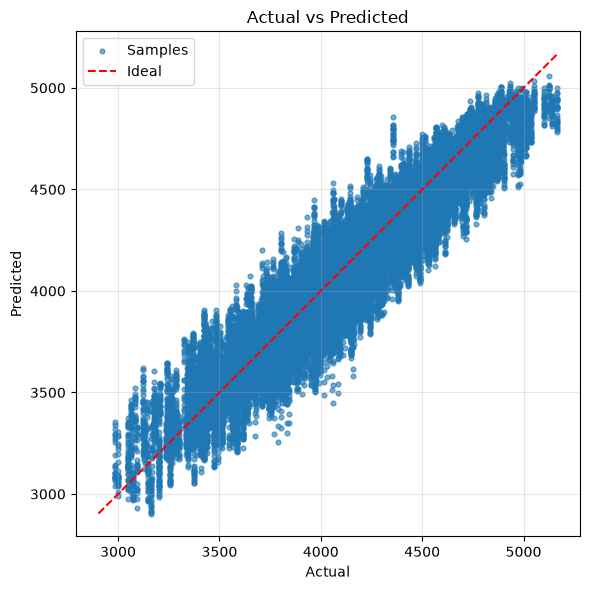

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# --- ensure shapes are compatible ---
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

print("Pred shape:", pred.shape)
print("Act shape:", act.shape)

# --- scatter plot ---
plt.figure(figsize=(6,6))
plt.scatter(act, pred, s=12, alpha=0.6, label="Samples")

# --- 1:1 reference line ---
min_v = min(act.min(), pred.min())
max_v = max(act.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


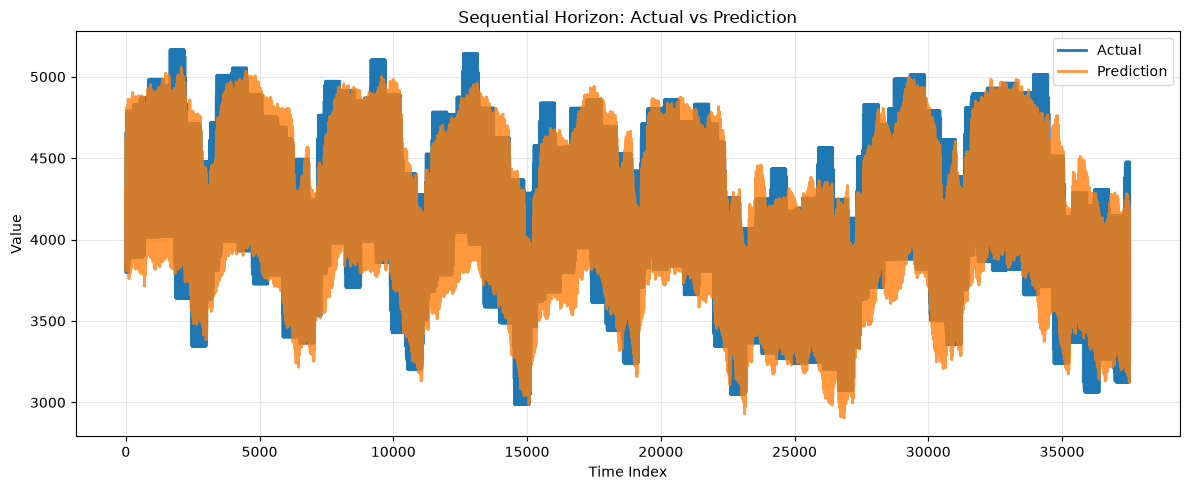

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten in case they are (N,1)
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

# Create a time index
t = np.arange(len(pred))

plt.figure(figsize=(12,5))
plt.plot(t, act, label="Actual", linewidth=2)
plt.plot(t, pred, label="Prediction", linewidth=2, alpha=0.8)

plt.title("Sequential Horizon: Actual vs Prediction")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


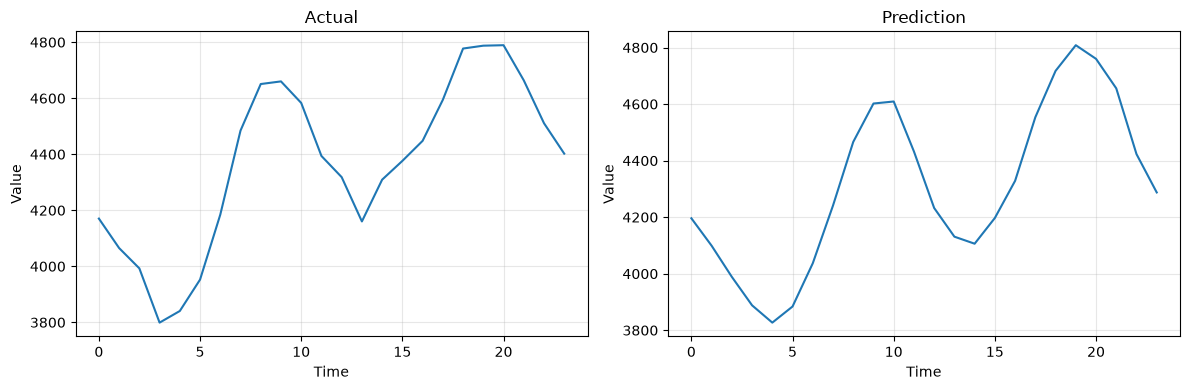

In [72]:
import matplotlib.pyplot as plt

# Select sample index
i = 1

actual = actuals_original[i, :, :]
pred   = predictions_original[i, :, :]

plt.figure(figsize=(12,4))

# --- Actual ---
plt.subplot(1, 2, 1)
plt.plot(actual)
plt.title("Actual")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

# --- Prediction ---
plt.subplot(1, 2, 2)
plt.plot(pred)
plt.title("Prediction")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


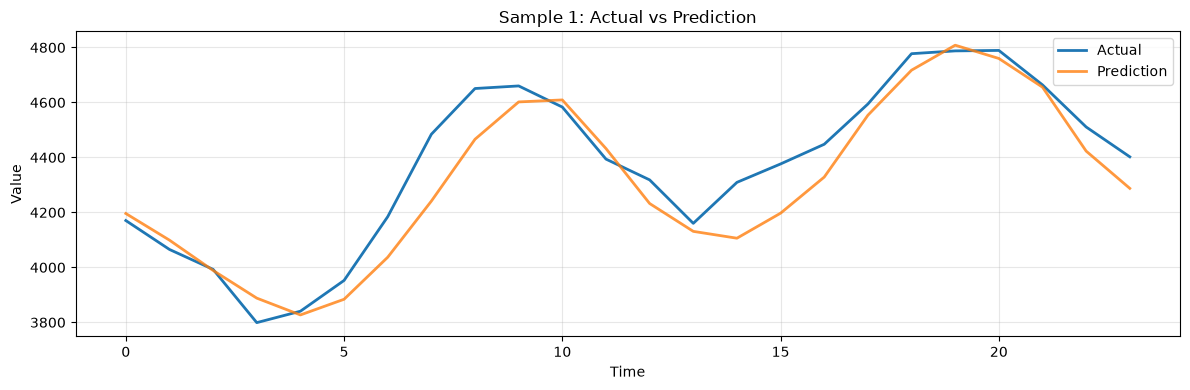

In [74]:
# Select sample index
i = 1

actual = actuals_original[i, :, :]
pred   = predictions_original[i, :, :]

plt.figure(figsize=(12,4))

plt.plot(actual, label="Actual", linewidth=2)
plt.plot(pred, label="Prediction", linewidth=2, alpha=0.8)

plt.title(f"Sample {i}: Actual vs Prediction")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
predictions = []
actuals = []
forecast_datetimes = []

model.eval()

with torch.no_grad():

    for i, (X, y) in enumerate(test_loader):

        X = X.to(device)

        prediction = model(X)

        prediction = prediction.cpu().numpy()
        actual = y.numpy()

        # Process each sample in the batch
        for j in range(len(prediction)):

            sample_index = i * test_loader.batch_size + j

            # Forecast starts after the lookback period
            forecast_start_index = loader.lookback + sample_index

            # Get forecast start timestamp
            forecast_start_time = test_df[
                loader.datetime_col
            ].iloc[forecast_start_index]

            # Only keep forecasts starting at midnight # sk
            if forecast_start_time.hour == 0:

                predictions.append(prediction[j])
                actuals.append(actual[j])

                forecast_datetimes.append(
                    test_df[
                        loader.datetime_col
                    ].iloc[
                        forecast_start_index:
                        forecast_start_index + loader.horizon
                    ].values
                )

In [81]:
predictions = np.array(predictions)
actuals = np.array(actuals)
forecast_datetimes = np.array(forecast_datetimes)

print("Predictions:", predictions.shape)
print("Actual:", actuals.shape)
print("Forecast dates:", forecast_datetimes.shape)

Predictions: (66, 24, 1)
Actual: (66, 24, 1)
Forecast dates: (66, 24)


In [82]:
predictions_original = (
    target_scaler.inverse_transform(
        predictions.reshape(-1, 1)
    )
    .reshape(predictions.shape)
)

actuals_original = (
    target_scaler.inverse_transform(
        actuals.reshape(-1, 1)
    )
    .reshape(actuals.shape)
)

In [85]:
predictions_original.shape

(66, 24, 1)

In [86]:
results = []

for day in range(len(predictions_original)):

    for hour in range(loader.horizon):

        results.append({
            "forecast_date": forecast_datetimes[day, 0],
            "datetime": forecast_datetimes[day, hour],
            "actual": actuals_original[day, hour, 0],
            "predicted": predictions_original[day, hour, 0]
        })

results_df = pd.DataFrame(results)

In [87]:
results_df

,forecast_date,datetime,actual,predicted
0,2023-01-24,2023-01-24 00:00:00,4065.200195,4081.790039
1,2023-01-24,2023-01-24 01:00:00,3992.700195,3983.740723
2,2023-01-24,2023-01-24 02:00:00,3799.000000,3879.051514
3,2023-01-24,2023-01-24 03:00:00,3840.500000,3826.135742
4,2023-01-24,2023-01-24 04:00:00,3952.500000,3810.611084
...,...,...,...,...
1579,2023-03-30,2023-03-30 19:00:00,4311.200195,3992.952881
1580,2023-03-30,2023-03-30 20:00:00,4061.600098,3842.129883
1581,2023-03-30,2023-03-30 21:00:00,3897.300049,3692.936279
1582,2023-03-30,2023-03-30 22:00:00,3814.500000,3540.844971


In [88]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


mae = mean_absolute_error(
    actuals_original.flatten(),
    predictions_original.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        actuals_original.flatten(),
        predictions_original.flatten()
    )
)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  121.95
RMSE: 151.78


In [92]:
results_df["error"] = (
    results_df["predicted"] - results_df["actual"]
)

results_df["absolute_error"] = (
    results_df["error"].abs()
)

results_df["percentage_error"] = (
    results_df["error"]
    / results_df["actual"].replace(0, np.nan)
) * 100

## Error for each forecast hour

results_df["forecast_hour"] = (
    results_df["datetime"].dt.hour
)

# group by forecast hour and calculate mean error and MAE
hourly_error = (
    results_df
    .groupby("forecast_hour")
    .agg(
        mean_error=("error", "mean"),
        std_error=("error", "std"),
        mae=("absolute_error", "mean")
    )
    .reset_index()
)

print(hourly_error)

    forecast_hour  mean_error   std_error         mae
0               0   -1.209029  128.711395  106.450722
1               1  -16.462851  114.705688   93.800674
2               2  -38.703308  115.851486  103.266632
3               3  -59.825672  116.932167  107.016190
4               4 -114.592514  128.249756  139.482834
5               5  -78.030396  126.459831  120.869507
6               6  -95.153084  122.793419  126.600021
7               7  -96.107765  123.093109  125.143761
8               8  -69.965958  140.014313  126.362900
9               9  -51.276211  130.778015  113.095993
10             10   11.800004  127.139076  105.473358
11             11   -8.725568  126.801628  105.252991
12             12  -53.485683  131.139618  112.715446
13             13  -89.961456  137.017700  131.849106
14             14  -65.348022  136.368744  116.332764
15             15  -44.741047  144.980576  116.697350
16             16  -43.868008  142.562668  119.103615
17             17  -37.76409

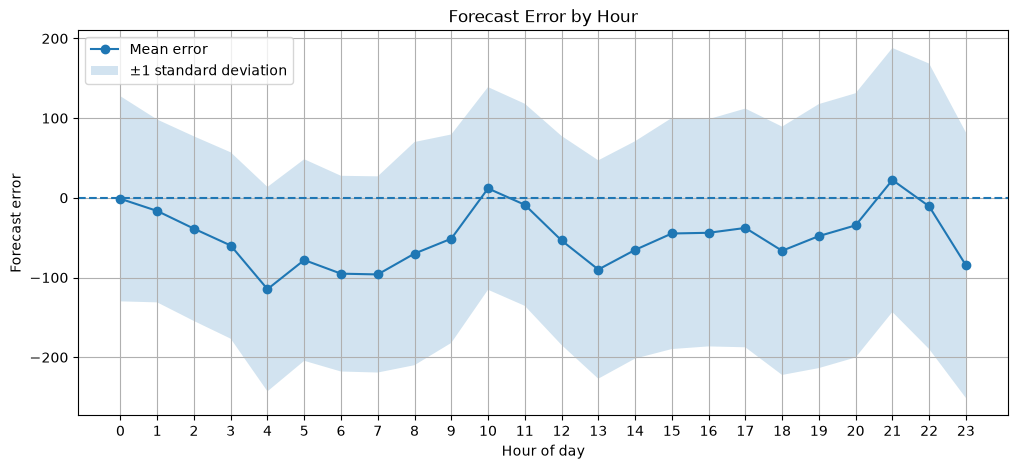

<Figure size 640x480 with 0 Axes>

In [94]:
import matplotlib.pyplot as plt

x = hourly_error["forecast_hour"]
mean = hourly_error["mean_error"]
std = hourly_error["std_error"]

plt.figure(figsize=(12, 5))

plt.plot(
    x,
    mean,
    marker="o",
    label="Mean error"
)

plt.fill_between(
    x,
    mean - std,
    mean + std,
    alpha=0.2,
    label="±1 standard deviation"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Hour of day")
plt.ylabel("Forecast error")
plt.title("Forecast Error by Hour")
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()
plt.savefig(f"{SAVE_DIR}/forecast_error_by_hour_Mean_std.png", dpi=300)

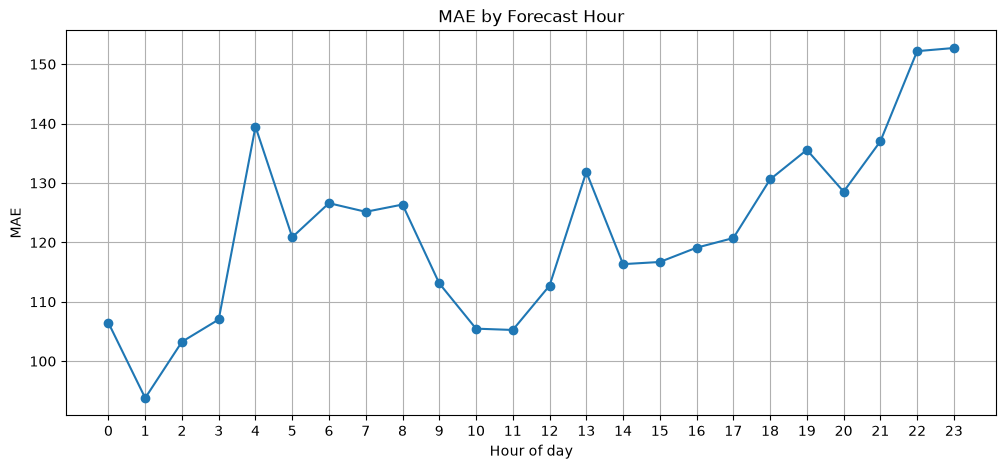

<Figure size 640x480 with 0 Axes>

In [95]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_error["forecast_hour"],
    hourly_error["mae"],
    marker="o"
)

plt.xlabel("Hour of day")
plt.ylabel("MAE")
plt.title("MAE by Forecast Hour")
plt.xticks(range(24))
plt.grid(True)

plt.show()
plt.savefig(f"{SAVE_DIR}/forecast_error_by_hour_MAE.png", dpi=300)

Pred shape: (1584,)
Act shape: (1584,)


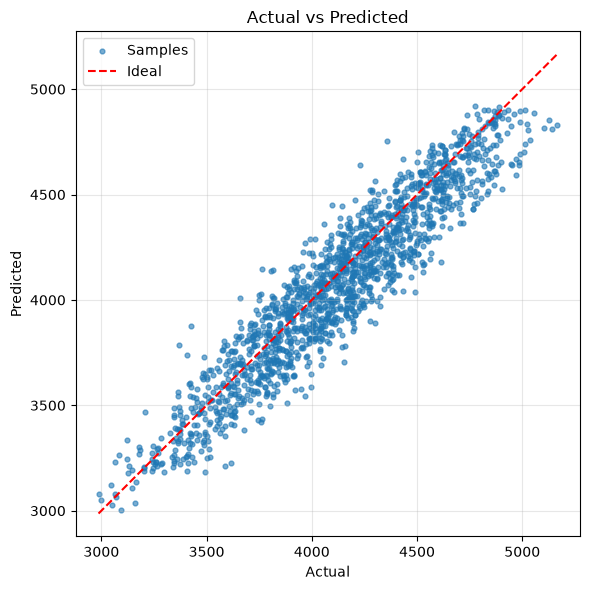

In [96]:
# --- ensure shapes are compatible ---
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

print("Pred shape:", pred.shape)
print("Act shape:", act.shape)

# --- scatter plot ---
plt.figure(figsize=(6,6))
plt.scatter(act, pred, s=12, alpha=0.6, label="Samples")

# --- 1:1 reference line ---
min_v = min(act.min(), pred.min())
max_v = max(act.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
